## "Há evidências de que filmes de ação lançados a partir de 2005 apresentam desempenho comercial inferior aos lançados anteriormente?"

A partir desse questionamento, podemos olhar mais especificamente para três dados(Colunas) em especifico: 

**Year**(O ano em que foi lançado o filme) <br> <br>
**World Wide Sales (in $)** (Que é o montante total que o filme lucrou mundialmente). <br> <br>
**Genre** (Que é o genero do filme em questão)

Primeiro precisamos filtrar os dados para pegar apenas os dados de filmes de ação e para valores que fazem sentido em ano(> 1900) e venda(> 0):

In [2]:
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os

handle = "sanjeetsinghnaik/top-1000-highest-grossing-movies"
file_path = "Highest Holywood Grossing Movies.csv"

df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, handle, file_path)
df.head()


C:\Users\gabri\AppData\Local\Temp\ipykernel_12216\2974614052.py:12: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, handle, file_path)


,Unnamed: 0,Title,Movie Info,Year,Distributor,Budget (in $),Domestic Opening (in $),Domestic Sales (in $),International Sales (in $),World Wide Sales (in $),Release Date,Genre,Running Time,License
0,0,Avatar,A paraplegic Marine dispatched to the moon Pan...,2009,Twentieth Century Fox,237000000,77025481,785221649,2138484377,2923706026,16-Dec-09,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 42 min,PG-13
1,1,Avengers: Endgame,After the devastating events of Avengers: Infi...,2019,Walt Disney Studios Motion Pictures,356000000,357115007,858373000,1941066100,2799439100,24-Apr-19,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13
2,2,Avatar: The Way of Water,Jake Sully lives with his newfound family form...,2022,20th Century Studios,December 14 2022 (EMEA APAC),134100226,684075767,1636174514,2320250281,24-Apr-19,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13
3,3,Titanic,A seventeen-year-old aristocrat falls in love ...,1997,Paramount Pictures,200000000,28638131,674292608,1590450697,2264743305,19-Dec-97,"['Drama', 'Romance']",3 hr 14 min,PG-13
4,4,Star Wars: Episode VII - The Force Awakens,"As a new threat to the galaxy rises, Rey, a de...",2015,Walt Disney Studios Motion Pictures,245000000,247966675,936662225,1134647993,2071310218,16-Dec-15,"['Action', 'Adventure', 'Sci-Fi']",2 hr 18 min,PG-13


In [12]:
df_action = df[
    df["Genre"].apply(lambda generos: "Action" in generos)
    & (df["Year"] >= 1900)
    & (df["World Wide Sales (in $)"] >= 0)
].copy()

df_action[["Title", "Year", "Genre", "World Wide Sales (in $)"]]

,Title,Year,Genre,World Wide Sales (in $)
0,Avatar,2009,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2923706026
1,Avengers: Endgame,2019,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",2799439100
2,Avatar: The Way of Water,2022,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",2320250281
4,Star Wars: Episode VII - The Force Awakens,2015,"['Action', 'Adventure', 'Sci-Fi']",2071310218
5,Avengers: Infinity War,2018,"['Action', 'Adventure', 'Sci-Fi']",2052415039
...,...,...,...,...
991,Hot Shots!,1991,"['Action', 'Comedy']",181096164
993,Kill Bill: Vol. 1,2003,"['Action', 'Crime', 'Thriller']",180906076
994,The Scorpion King,2002,"['Action', 'Adventure', 'Fantasy']",180630907
998,Deja Vu,2006,"['Action', 'Crime', 'Sci-Fi', 'Thriller']",180557550


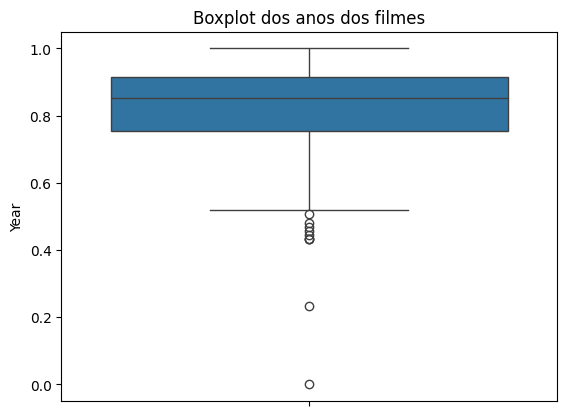

Mediana dos anos: 0.8518518518518519
Média dos anos: 0.8233936035773306
Q1: 0.7530864197530864
Q2: 0.8518518518518519
Q3: 0.9135802469135802
Q4: 1.0
Amplitude: 1.0 anos
Variância: 0.016382655231247635
Desvio padrão: 0.12799474688926743



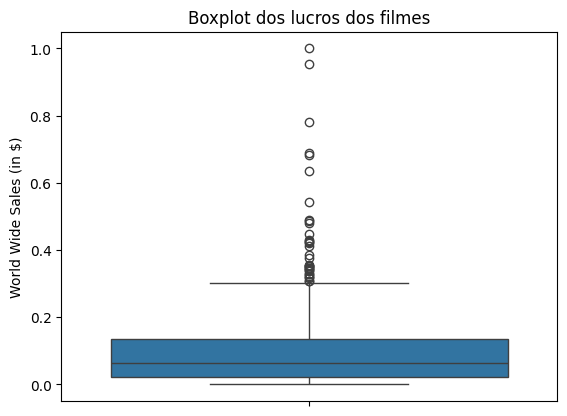

Mediana das vendas mundiais: 0.062340848799228986
Média das vendas mundiais: 0.10400551048780654
Q1: 0.02208459825816267
Q2: 0.062340848799228986
Q3: 0.1359234618528344
Q4: 1.0
Amplitude: 1.0
Variância: 0.015962893846005764
Desvio padrão: 0.12634434631595418


In [18]:
df_normalizado = df_action.copy()

df_normalizado["Year"] = (
    (df_action["Year"] - df_action["Year"].min()) /
    (df_action["Year"].max() - df_action["Year"].min())
)

df_normalizado["World Wide Sales (in $)"] = (
    (df_action["World Wide Sales (in $)"] - df_action["World Wide Sales (in $)"].min()) /
    (df_action["World Wide Sales (in $)"].max() - df_action["World Wide Sales (in $)"].min())
)
sns.boxplot(y=df_normalizado['Year'])
plt.title("Boxplot dos anos dos filmes")
plt.show()

print(f"Mediana dos anos: {df_normalizado['Year'].median()}\nMédia dos anos: {df_normalizado['Year'].mean()}")
print(f"Q1: {df_normalizado['Year'].quantile(.25)}\nQ2: {df_normalizado['Year'].quantile(.50)}\nQ3: {df_normalizado['Year'].quantile(.75)}\nQ4: {df_normalizado['Year'].quantile(1.00)}")
print(f"Amplitude: {df_normalizado['Year'].max() - df_normalizado['Year'].min()} anos")
print(f"Variância: {df_normalizado['Year'].var()}")
print(f"Desvio padrão: {df_normalizado['Year'].std()}")
print()

sns.boxplot(y=df_normalizado['World Wide Sales (in $)'])
plt.title("Boxplot dos lucros dos filmes")
plt.show()

print(
    f"Mediana das vendas mundiais: {df_normalizado['World Wide Sales (in $)'].median()}\n"
    f"Média das vendas mundiais: {df_normalizado['World Wide Sales (in $)'].mean()}"
)
print(
    f"Q1: {df_normalizado['World Wide Sales (in $)'].quantile(0.25)}\n"
    f"Q2: {df_normalizado['World Wide Sales (in $)'].quantile(0.50)}\n"
    f"Q3: {df_normalizado['World Wide Sales (in $)'].quantile(0.75)}\n"
    f"Q4: {df_normalizado['World Wide Sales (in $)'].quantile(1.00)}"
)
print(f"Amplitude: {df_normalizado['World Wide Sales (in $)'].max() - df_normalizado['World Wide Sales (in $)'].min()}")
print(f"Variância: {df_normalizado['World Wide Sales (in $)'].var()}")
print(f"Desvio padrão: {df_normalizado['World Wide Sales (in $)'].std()}")



### Ano
Podemos observar a partir dos graficos e das informações que a maioria dos filmes está concentrado nos anos mais atuais com poucos filmes bem mais antigos. Podemos concluir isso observando os quartis e o intervalo entre eles. a maioria dos filmes está entre 2002 a 2023. O que ajuda na compreensão desses dados também, é a amplitude muito alta (86 anos) e mesmo assim, uma variância (10 anos) pequena em relação a amplitude, sugerindo uma grande concentração desses dados nos anos mais recente.<br> <br>
### Lucro
Juntamente com isso, pode-se observar que os maiores lucros são alguns outliers mas a maioria se concentra bem abaixo da media. O que sugere que há bilheterias muito altas puxando o valor para cima (outliers). Outro dado que reforça isso é o desvio padrão muito alto, mostrando uma grande variação nos valores de bilheteria.

#### Mas, para uma maior precisão, após aplicar esses filtros, precisamos dividir os dados em dois quadrantes:<br><br>

Pré 2005<br><br>
Pós 2005<br><br>

Tendo em vista que estamos lidando com escalas de valores distantes, para a melhor visualização em graficos do problema, o ideal é fazermos uma normalização dos dados. Mas para isso, ou qualquer outra operação que fizermos, precisamos descobrir como são os dados que estamos lidando. Ele tem muitos outliers?

Para isso, vou utilizar a media e mediana juntamente com uma visualização grafica de datagrama para tentar encontrar o maximo de outliers na relação entre o lucro mundial e o ano:

In [15]:
df_action_pre = df_action[
    df_action['Year'] >= 2005
    ]

df_action_pos = df_action[
    df_action['Year'] < 2005
    ]

# Pré-2005

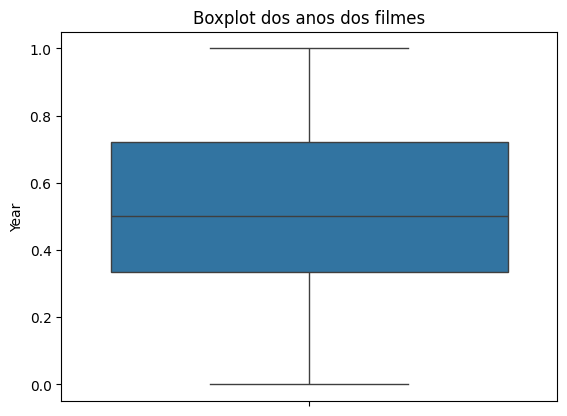

Mediana dos anos: 0.5
Média dos anos: 0.5110799001248439
Q1: 0.3333333333333333
Q2: 0.5
Q3: 0.7222222222222222
Q4: 1.0
Amplitude: 1.0 anos
Variância: 0.06776943042636453
Desvio padrão: 0.2603256238374635



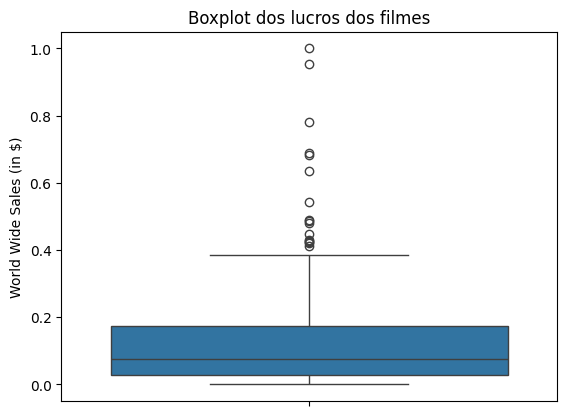

Mediana das vendas mundiais: 0.07514255466292474
Média das vendas mundiais: 0.12216816892736809
Q1: 0.026737597903570026
Q2: 0.07514255466292474
Q3: 0.17418400947315527
Q4: 1.0
Amplitude: 1.0
Variância: 0.019708664104421236
Desvio padrão: 0.14038754967738853


In [16]:
df_normalizado_pre = df_action_pre.copy()

df_normalizado_pre["Year"] = (
    (df_action_pre["Year"] - df_action_pre["Year"].min()) /
    (df_action_pre["Year"].max() - df_action_pre["Year"].min())
)

df_normalizado_pre["World Wide Sales (in $)"] = (
    (df_action_pre["World Wide Sales (in $)"] - df_action_pre["World Wide Sales (in $)"].min()) /
    (df_action_pre["World Wide Sales (in $)"].max() - df_action_pre["World Wide Sales (in $)"].min())
)
sns.boxplot(y=df_normalizado_pre['Year'])
plt.title("Boxplot dos anos dos filmes")
plt.show()

print(f"Mediana dos anos: {df_normalizado_pre['Year'].median()}\nMédia dos anos: {df_normalizado_pre['Year'].mean()}")
print(f"Q1: {df_normalizado_pre['Year'].quantile(.25)}\nQ2: {df_normalizado_pre['Year'].quantile(.50)}\nQ3: {df_normalizado_pre['Year'].quantile(.75)}\nQ4: {df_normalizado_pre['Year'].quantile(1.00)}")
print(f"Amplitude: {df_normalizado_pre['Year'].max() - df_normalizado_pre['Year'].min()} anos")
print(f"Variância: {df_normalizado_pre['Year'].var()}")
print(f"Desvio padrão: {df_normalizado_pre['Year'].std()}")
print()

sns.boxplot(y=df_normalizado_pre['World Wide Sales (in $)'])
plt.title("Boxplot dos lucros dos filmes")
plt.show()

print(
    f"Mediana das vendas mundiais: {df_normalizado_pre['World Wide Sales (in $)'].median()}\n"
    f"Média das vendas mundiais: {df_normalizado_pre['World Wide Sales (in $)'].mean()}"
)
print(
    f"Q1: {df_normalizado_pre['World Wide Sales (in $)'].quantile(0.25)}\n"
    f"Q2: {df_normalizado_pre['World Wide Sales (in $)'].quantile(0.50)}\n"
    f"Q3: {df_normalizado_pre['World Wide Sales (in $)'].quantile(0.75)}\n"
    f"Q4: {df_normalizado_pre['World Wide Sales (in $)'].quantile(1.00)}"
)
print(f"Amplitude: {df_normalizado_pre['World Wide Sales (in $)'].max() - df_normalizado_pre['World Wide Sales (in $)'].min()}")
print(f"Variância: {df_normalizado_pre['World Wide Sales (in $)'].var()}")
print(f"Desvio padrão: {df_normalizado_pre['World Wide Sales (in $)'].std()}")

# Pós-2005

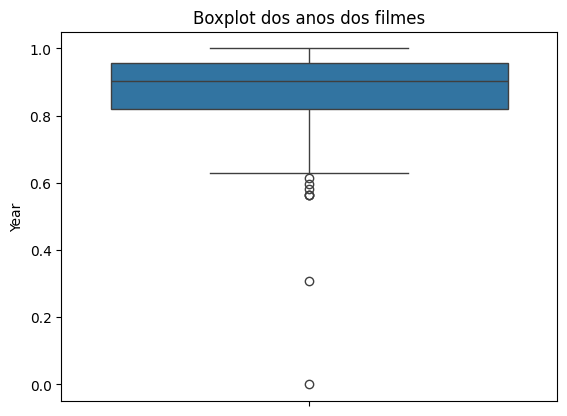

Mediana dos anos: 0.9032258064516129
Média dos anos: 0.8677843803056028
Q1: 0.8185483870967742
Q2: 0.9032258064516129
Q3: 0.9556451612903226
Q4: 1.0
Amplitude: 1.0 anos
Variância: 0.018348159249416688
Desvio padrão: 0.13545537733665905



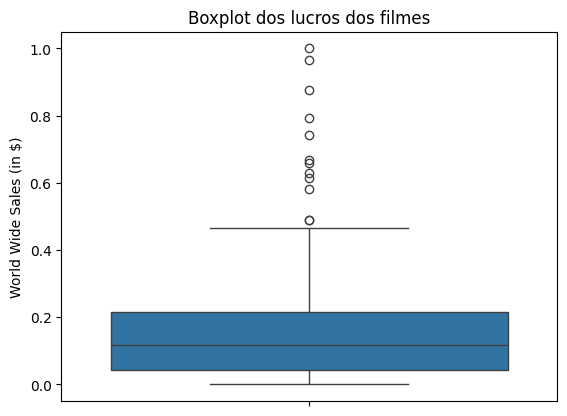

Mediana das vendas mundiais: 0.11681090973244893
Média das vendas mundiais: 0.17371850673098224
Q1: 0.043369457446708906
Q2: 0.11681090973244893
Q3: 0.2165836758285052
Q4: 1.0
Amplitude: 1.0
Variância: 0.03754048187038526
Desvio padrão: 0.19375366285669351


In [17]:
df_normalizado_pos = df_action_pos.copy()

df_normalizado_pos["Year"] = (
    (df_action_pos["Year"] - df_action_pos["Year"].min()) /
    (df_action_pos["Year"].max() - df_action_pos["Year"].min())
)

df_normalizado_pos["World Wide Sales (in $)"] = (
    (df_action_pos["World Wide Sales (in $)"] - df_action_pos["World Wide Sales (in $)"].min()) /
    (df_action_pos["World Wide Sales (in $)"].max() - df_action_pos["World Wide Sales (in $)"].min())
)
sns.boxplot(y=df_normalizado_pos['Year'])
plt.title("Boxplot dos anos dos filmes")
plt.show()

print(f"Mediana dos anos: {df_normalizado_pos['Year'].median()}\nMédia dos anos: {df_normalizado_pos['Year'].mean()}")
print(f"Q1: {df_normalizado_pos['Year'].quantile(.25)}\nQ2: {df_normalizado_pos['Year'].quantile(.50)}\nQ3: {df_normalizado_pos['Year'].quantile(.75)}\nQ4: {df_normalizado_pos['Year'].quantile(1.00)}")
print(f"Amplitude: {df_normalizado_pos['Year'].max() - df_normalizado_pos['Year'].min()} anos")
print(f"Variância: {df_normalizado_pos['Year'].var()}")
print(f"Desvio padrão: {df_normalizado_pos['Year'].std()}")
print()

sns.boxplot(y=df_normalizado_pos['World Wide Sales (in $)'])
plt.title("Boxplot dos lucros dos filmes")
plt.show()

print(
    f"Mediana das vendas mundiais: {df_normalizado_pos['World Wide Sales (in $)'].median()}\n"
    f"Média das vendas mundiais: {df_normalizado_pos['World Wide Sales (in $)'].mean()}"
)
print(
    f"Q1: {df_normalizado_pos['World Wide Sales (in $)'].quantile(0.25)}\n"
    f"Q2: {df_normalizado_pos['World Wide Sales (in $)'].quantile(0.50)}\n"
    f"Q3: {df_normalizado_pos['World Wide Sales (in $)'].quantile(0.75)}\n"
    f"Q4: {df_normalizado_pos['World Wide Sales (in $)'].quantile(1.00)}"
)
print(f"Amplitude: {df_normalizado_pos['World Wide Sales (in $)'].max() - df_normalizado_pos['World Wide Sales (in $)'].min()}")
print(f"Variância: {df_normalizado_pos['World Wide Sales (in $)'].var()}")
print(f"Desvio padrão: {df_normalizado_pos['World Wide Sales (in $)'].std()}")